# Jour 3 — CNN : pneumonie bactérienne vs virale (radiographie thoracique)

Classification binaire d'images en trois itérations sur le même problème :

1. TP1 — CNN from scratch (overfitting attendu)
2. TP2 — CNN + data augmentation + Dropout
3. TP3 — Transfer learning MobileNetV2

Modèle éducatif : il ne constitue en aucun cas un outil de diagnostic médical.

Dataset : radiographies de pneumonie labellisées bactérienne / virale (Kaggle, ~3 900 images). On ne garde que les clichés pathologiques et on distingue l'origine de l'infection — une tâche fine bien plus difficile que « normal vs pneumonie » : les deux motifs (consolidation lobaire bactérienne, atteinte interstitielle diffuse virale) se recouvrent largement, y compris pour un radiologue. Les classes sont déséquilibrées (~1,9:1 en faveur du bactérien) ; on le traite avec `class_weight` à l'entraînement, pas en jetant des données.

## Phase 1.1 — Setup et organisation du dataset

Télécharger le dataset via l'API Kaggle, nettoyer l'archive, puis organiser les images en `train` / `val` / `test` par classe.

Le dataset ne fournit pas de dossiers `bacteria` / `virus` : le type d'infection est encodé dans le nom de chaque fichier de pneumonie (`personXX_bacteria_YY.jpeg`, `personXX_virus_YY.jpeg`). On trie donc les images sur ce motif et on ignore les clichés `normal`.

- **test** : le split officiel du dataset (patient-disjoint), conservé tel quel pour une évaluation finale honnête.
- **train / val** : le `val` officiel ne fait que 16 images, donc on regroupe train + val officiels et on refait un split 80/20 (`seed=42`).

Environnement : conteneur Docker (TensorFlow CPU). Identifiants Kaggle via `KAGGLE_USERNAME` / `KAGGLE_KEY` (`.env`). Données dans des volumes Docker (`/tf/raw`, `/tf/data`).

In [1]:
# Seul endroit à modifier pour changer de dataset.
CLASS_A = 'bacteria'
CLASS_B = 'virus'

# Les deux classes vivent dans le même dossier PNEUMONIA de l'archive ; on les
# distingue par un motif présent dans le nom de fichier (personXX_bacteria_YY.jpeg).
CLASS_SRC = 'PNEUMONIA'

# Volumes Docker (rapides, hors bind mount Windows).
RAW_ROOT  = '/tf/raw'
DATA_ROOT = '/tf/data'

KAGGLE_DATASET = 'paultimothymooney/chest-xray-pneumonia'

# Entrée réseau : 64-160 px conseillé, 128 = compromis détail / temps CPU.
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [2]:
import os, subprocess, shutil

# Identifiants lus depuis KAGGLE_USERNAME / KAGGLE_KEY (voir .env). ~2,3 Go au premier run.
os.makedirs(RAW_ROOT, exist_ok=True)
if not any(os.scandir(RAW_ROOT)):
    subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', KAGGLE_DATASET,
         '-p', RAW_ROOT, '--unzip', '-q'],
        check=True,
    )
    print('Téléchargement terminé.')
else:
    print('Dataset déjà présent, téléchargement ignoré.')

# Nettoyage de l'archive : ce dataset embarque une copie imbriquée chest_xray/chest_xray
# et des dossiers __MACOSX (métadonnées macOS). On les retire pour garder une structure
# propre : chest_xray/{train,val,test}/{NORMAL,PNEUMONIA}.
nested = os.path.join(RAW_ROOT, 'chest_xray', 'chest_xray')
if os.path.isdir(nested):
    shutil.rmtree(nested)
    print('Retiré : chest_xray/chest_xray')
for dirpath, dirs, files in os.walk(RAW_ROOT):
    if '__MACOSX' in dirs:
        shutil.rmtree(os.path.join(dirpath, '__MACOSX'))
        dirs.remove('__MACOSX')
        print('Retiré :', os.path.join(os.path.relpath(dirpath, RAW_ROOT), '__MACOSX'))

Dataset déjà présent, téléchargement ignoré.


In [3]:
# Structure du dataset après nettoyage.
for dirpath, dirs, files in os.walk(os.path.join(RAW_ROOT, 'chest_xray')):
    imgs = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    niveau = dirpath.replace(RAW_ROOT, '').count(os.sep)
    print('  ' * niveau, os.path.basename(dirpath), '->', len(imgs), 'images')

   chest_xray -> 0 images
     val -> 0 images
       NORMAL -> 8 images
       PNEUMONIA -> 8 images
     test -> 0 images
       NORMAL -> 234 images
       PNEUMONIA -> 390 images
     train -> 0 images
       NORMAL -> 1341 images
       PNEUMONIA -> 3875 images


In [4]:
import random

BASE = os.path.join(RAW_ROOT, 'chest_xray')
IMG_EXT = ('.jpg', '.jpeg', '.png')

def images_in(split, cls):
    # Images du dossier PNEUMONIA dont le nom contient le motif de la classe.
    d = os.path.join(BASE, split, CLASS_SRC)
    if not os.path.isdir(d):
        return []
    return [os.path.join(d, f) for f in os.listdir(d)
            if f.lower().endswith(IMG_EXT) and not f.startswith('._') and cls in f.lower()]

def copy_to(paths, split, cls):
    dst = os.path.join(DATA_ROOT, split, cls)
    os.makedirs(dst, exist_ok=True)
    for i, src in enumerate(paths):
        ext = os.path.splitext(src)[1].lower()
        shutil.copy(src, os.path.join(dst, f'{cls}_{i:05d}{ext}'))

# Repartir de dossiers propres. DATA_ROOT est un point de montage : on vide son
# contenu au lieu de le supprimer lui-même.
if os.path.isdir(DATA_ROOT):
    for e in os.scandir(DATA_ROOT):
        shutil.rmtree(e.path) if e.is_dir() else os.remove(e.path)

random.seed(42)
for cls in [CLASS_A, CLASS_B]:
    # test : split officiel conservé tel quel (patient-disjoint).
    copy_to(images_in('test', cls), 'test', cls)
    # train/val : regroupe train + val officiels puis re-split 80/20.
    pool = images_in('train', cls) + images_in('val', cls)
    random.shuffle(pool)
    n_val = int(len(pool) * 0.2)
    copy_to(pool[:n_val], 'val', cls)
    copy_to(pool[n_val:], 'train', cls)

In [5]:
# Comptes par split et par classe : le déséquilibre ~1,9:1 doit rester visible.
for split in ['train', 'val', 'test']:
    for cls in [CLASS_A, CLASS_B]:
        path = os.path.join(DATA_ROOT, split, cls)
        print(f'{path} : {len(os.listdir(path))} images')

/tf/data/train/bacteria : 2031 images
/tf/data/train/virus : 1076 images
/tf/data/val/bacteria : 507 images
/tf/data/val/virus : 269 images
/tf/data/test/bacteria : 242 images
/tf/data/test/virus : 148 images


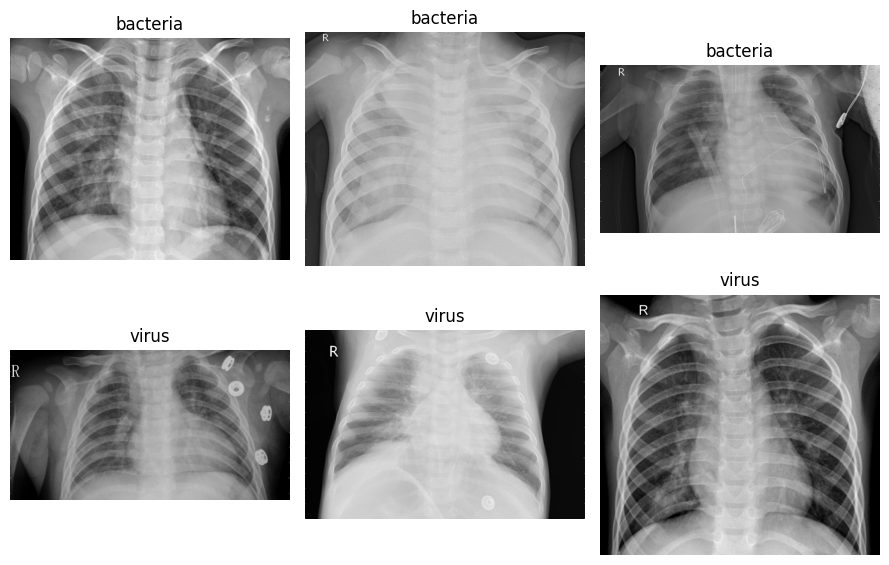

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(9, 6))
for i, cls in enumerate([CLASS_A, CLASS_B]):
    folder = os.path.join(DATA_ROOT, 'train', cls)
    for j, fname in enumerate(os.listdir(folder)[:3]):
        img = mpimg.imread(os.path.join(folder, fname))
        plt.subplot(2, 3, i * 3 + j + 1)
        plt.imshow(img, cmap='gray')
        plt.title(cls)
        plt.axis('off')
plt.tight_layout()
plt.show()

## Phase 1.2 — Preprocessing : normalisation + batching

Chargement avec `image_dataset_from_directory` (`label_mode='binary'` : bacteria=0, virus=1 par ordre alphabétique), normalisation des pixels en [0,1] avec `Rescaling(1./255)`, puis `cache()` + `prefetch()` pour ne pas relire le disque à chaque epoch. `shuffle=True` sur train uniquement ; le val set garde un ordre fixe pour des évaluations reproductibles.

In [7]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, 'train'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=True,
    seed=42,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_ROOT, 'val'),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False,
    seed=42,
)
print('Classes :', train_ds.class_names)

2026-07-16 13:44:05.055305: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-16 13:44:05.164122: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Found 3107 files belonging to 2 classes.


Found 776 files belonging to 2 classes.


Classes : ['bacteria', 'virus']


In [8]:
# Rescaling en [0,1] pour TP1/TP2 ; TP3 utilisera preprocess_input à la place.
normalization_layer = tf.keras.layers.Rescaling(1./255)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(buffer_size=AUTOTUNE)

In [9]:
# Vérification du premier batch : shapes et plage de valeurs après Rescaling.
images, labels = next(iter(train_ds))
print('Shape images batch :', images.shape)
print('Shape labels batch :', labels.shape)
print(f'Valeurs : min = {tf.reduce_min(images):.2f}, max = {tf.reduce_max(images):.2f}')

Shape images batch : (32, 128, 128, 3)
Shape labels batch : (32, 1)
Valeurs : min = 0.00, max = 1.00


2026-07-16 13:44:08.760470: W tensorflow/core/kernels/data/cache_dataset_ops.cc:914] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


## Phase 1.3 — Architecture CNN from scratch

Trois blocs Conv2D + MaxPooling, puis Flatten et deux Dense. Avec `padding='same'`, chaque Conv2D conserve H×W et seul le MaxPooling (2,2) divise par 2. Calcul des shapes à la main pour une entrée 128×128×3 :

| Couche | Shape en sortie | Paramètres |
|---|---|---|
| Conv2D(32) + MaxPool | (64, 64, 32) | 3×3×3×32 + 32 = 896 |
| Conv2D(64) + MaxPool | (32, 32, 64) | 3×3×32×64 + 64 = 18 496 |
| Conv2D(128) + MaxPool | (16, 16, 128) | 3×3×64×128 + 128 = 73 856 |
| Flatten | (32 768,) | 0 |
| Dense(128) | (128,) | 32 768×128 + 128 = 4 194 432 |
| Dense(1, sigmoid) | (1,) | 129 |

Total attendu : **4 287 809 paramètres**, dont l'écrasante majorité dans le Dense après Flatten — c'est cette couche qui donnera au modèle sa capacité à mémoriser (et donc à overfitter).

In [10]:
from tensorflow.keras import layers, models

def build_cnn_scratch(input_shape):
    """CNN from scratch pour la classification binaire.

    Architecture délibérément simple : on veut voir l'overfitting, pas l'éviter.
    """
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])
    return model

model_scratch = build_cnn_scratch(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
model_scratch.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model_scratch.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

## Phase 1.4 — Entraînement et diagnostic de l'overfitting

20 epochs avec deux callbacks : TensorBoard (suivi des courbes en temps réel) et EarlyStopping sur `val_loss` (patience 5, `restore_best_weights=True`). Le déséquilibre ~1,9:1 est compensé par `class_weight` : une erreur sur un cas `virus` (minoritaire) pèse plus lourd qu'une erreur sur un cas `bacteria`, sans quoi prédire systématiquement la classe majoritaire donnerait déjà ~65 % d'accuracy.

Comportement attendu (et recherché) : la train_accuracy grimpe pendant que la val_loss finit par remonter — le CNN sans régularisation mémorise le train set. C'est le point de comparaison des TP2 et TP3.

In [12]:
import datetime, time

# Un log par run, horodaté pour ne pas écraser les précédents.
log_dir = 'logs/scratch/' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True)

# Poids inversement proportionnels aux effectifs des classes.
n_a = len(os.listdir(os.path.join(DATA_ROOT, 'train', CLASS_A)))
n_b = len(os.listdir(os.path.join(DATA_ROOT, 'train', CLASS_B)))
class_weight = {0: (n_a + n_b) / (2 * n_a), 1: (n_a + n_b) / (2 * n_b)}
print('class_weight :', {k: round(v, 2) for k, v in class_weight.items()})

class_weight : {0: 0.76, 1: 1.44}


In [13]:
start = time.time()

# verbose=2 : une ligne par epoch, lisible dans le notebook versionné.
history_scratch = model_scratch.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[tensorboard_callback, early_stopping],
    class_weight=class_weight,
    verbose=2,
)

training_time_scratch = time.time() - start
print(f"Temps d'entraînement : {training_time_scratch:.0f}s")
print(f"val_accuracy finale : {max(history_scratch.history['val_accuracy']):.3f}")

Epoch 1/20


98/98 - 35s - 362ms/step - accuracy: 0.6678 - loss: 0.6132 - val_accuracy: 0.6869 - val_loss: 0.6258


Epoch 2/20


98/98 - 27s - 271ms/step - accuracy: 0.7300 - loss: 0.5587 - val_accuracy: 0.6881 - val_loss: 0.6098


Epoch 3/20


...

Epoch 7/20


98/98 - 26s - 270ms/step - accuracy: 0.7969 - loss: 0.4295 - val_accuracy: 0.7268 - val_loss: 0.6847


Epoch 8/20


98/98 - 27s - 272ms/step - accuracy: 0.8230 - loss: 0.3795 - val_accuracy: 0.6791 - val_loss: 0.7663


Temps d'entraînement : 239s
val_accuracy finale : 0.735


TensorBoard tourne en service dans le conteneur (`tensorboard --logdir /tf/work/logs --port 6006`, port publié par le docker-compose) : les courbes sont visibles sur http://localhost:6006 pendant l'entraînement. C'est l'équivalent Docker du `%tensorboard --logdir logs/` de Colab.

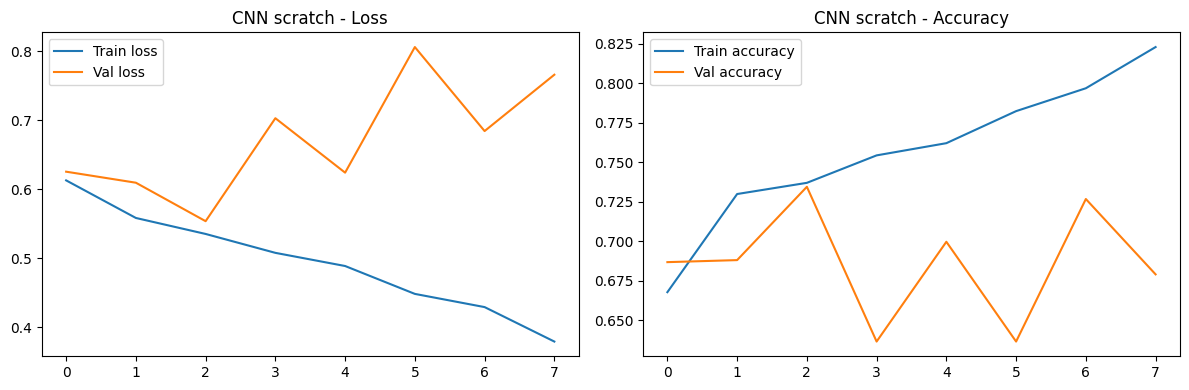

In [14]:
def plot_history(history, title=""):
    """Courbes loss/accuracy train vs val — réutilisée pour toutes les phases."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'], label='Train loss')
    ax1.plot(history.history['val_loss'], label='Val loss')
    ax1.set_title(f'{title} - Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"curves_{title.lower().replace(' ', '_')}.png", dpi=100)
    plt.show()

plot_history(history_scratch, "CNN scratch")

### Lecture des courbes

Overfitting manuel et net : la train loss descend régulièrement (0.61 → 0.38) pendant que la val loss diverge vers le haut (minimum 0.554 à l'**epoch 3**, puis remontée jusqu'à 0.81). La val_accuracy oscille en dents de scie (0.64 à 0.73) très en dessous de la train_accuracy, qui grimpe seule vers 82 %. L'EarlyStopping a coupé à l'epoch 8 (5 epochs sans amélioration après l'epoch 3) et restauré les poids du meilleur point : **val_accuracy ≈ 73,5 %**.

Contrairement à « normal vs pneumonie » (trop séparable, ~97 % dès la 2ᵉ epoch), bactérie vs virus est une tâche fine-grained difficile : les deux motifs radiologiques se recouvrent, le CNN from scratch n'a aucun a priori et se contente de mémoriser le train set sans généraliser. On retrouve donc bien le régime « ~70 % attendu » de l'énoncé, avec une vraie marge que les TP2 (régularisation) et TP3 (transfer learning) devront combler. Le test set officiel (patient-disjoint), volontairement mis de côté, donnera la mesure finale honnête en fin de TP3.

# TP2 — CNN régularisé (data augmentation + Dropout)

## Phase 2.1 — Pipeline d'augmentation

Couches d'augmentation Keras, actives uniquement en `training=True` (donc jamais sur le val/test set : la val_accuracy reste mesurée sur les images originales). Facteurs volontairement modérés pour rester réaliste sur des radiographies :

- `RandomFlip("horizontal")` : un poumon gauche/droite reste un thorax plausible.
- `RandomRotation(0.08)` (~14°) : sous le seuil 0.1 conseillé pour l'imagerie médicale — une rotation forte fausserait la lecture anatomique.
- `RandomZoom(0.1)` : simule de légères variations de cadrage.

Pas de `RandomFlip("vertical")` : une radio tête en bas n'existe pas dans le test set, l'ajouter apprendrait une invariance parasite.

In [15]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
], name="data_augmentation")

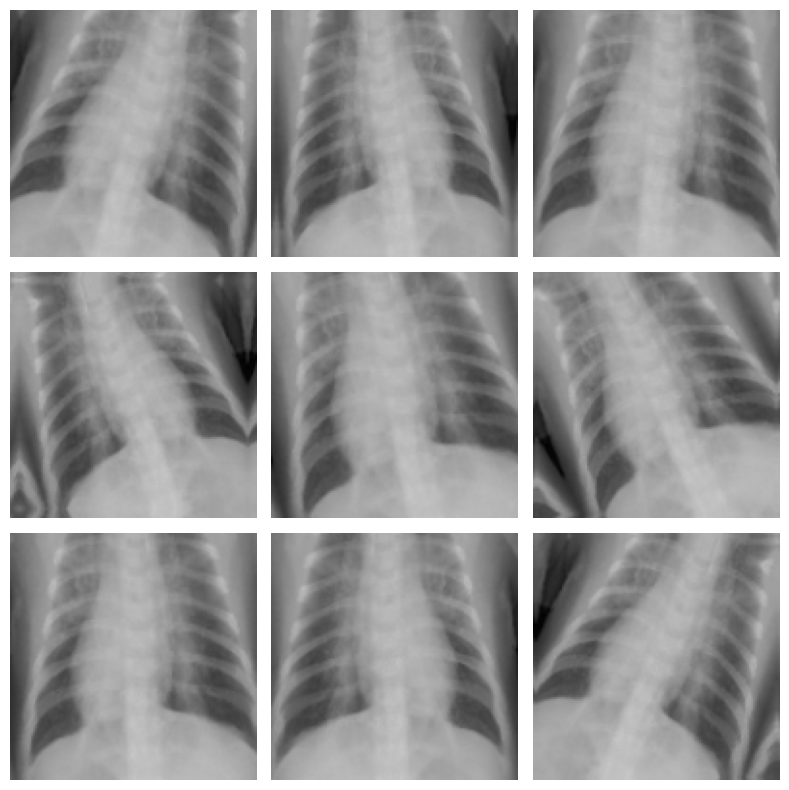

In [16]:
# Grille 3x3 : la même image sous 9 variations aléatoires, pour vérifier
# que les transformations restent réalistes.
sample_image = next(iter(train_ds))[0][0]

plt.figure(figsize=(8, 8))
for i in range(9):
    augmented = data_augmentation(tf.expand_dims(sample_image, 0), training=True)
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented[0])
    plt.axis('off')
plt.tight_layout()
plt.savefig("augmentation_grid.png", dpi=100)
plt.show()

## Phase 2.2 — Intégration du Dropout + réentraînement

Même architecture que TP1, avec deux ajouts : l'augmentation en tête de modèle et un `Dropout(0.4)` **après le Flatten** (jamais entre les blocs Conv, sinon on couperait des positions spatiales entières). Le Dropout éteint 40 % des activations à chaque batch, ce qui empêche le Dense de trop se reposer sur des neurones précis.

Réentraînement depuis zéro, mêmes hyperparamètres que TP1 (20 epochs, Adam, `class_weight`, mêmes callbacks) pour que la comparaison de la phase 2.3 soit honnête.

In [17]:
def build_cnn_augmented(input_shape):
    """Même base que build_cnn_scratch, avec augmentation intégrée et Dropout."""
    model = models.Sequential([
        layers.Input(shape=input_shape),
        data_augmentation,
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ])
    return model

model_augmented = build_cnn_augmented(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
model_augmented.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)
model_augmented.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
log_dir_aug = 'logs/augmented/' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
tensorboard_callback_aug = tf.keras.callbacks.TensorBoard(log_dir=log_dir_aug, histogram_freq=1)
early_stopping_aug = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True)

start = time.time()
history_augmented = model_augmented.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[tensorboard_callback_aug, early_stopping_aug],
    class_weight=class_weight,
    verbose=2,
)
training_time_augmented = time.time() - start
print(f"Temps d'entraînement : {training_time_augmented:.0f}s")
print(f"val_accuracy finale : {max(history_augmented.history['val_accuracy']):.3f}")

Epoch 1/20


98/98 - 30s - 308ms/step - accuracy: 0.5732 - loss: 0.6750 - val_accuracy: 0.6495 - val_loss: 0.7197


Epoch 2/20


98/98 - 33s - 339ms/step - accuracy: 0.6463 - loss: 0.6511 - val_accuracy: 0.4265 - val_loss: 0.7981


Epoch 3/20


...

Epoch 19/20


98/98 - 31s - 318ms/step - accuracy: 0.7155 - loss: 0.5821 - val_accuracy: 0.7448 - val_loss: 0.5752


Epoch 20/20


98/98 - 29s - 294ms/step - accuracy: 0.7132 - loss: 0.5823 - val_accuracy: 0.7397 - val_loss: 0.5794


Temps d'entraînement : 628s
val_accuracy finale : 0.747


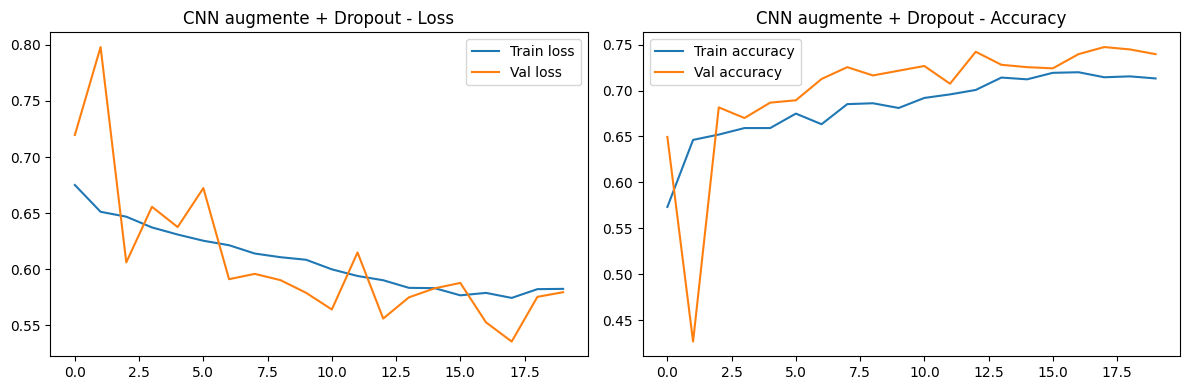

In [19]:
plot_history(history_augmented, "CNN augmente + Dropout")

### Lecture des courbes

La régularisation fait ce qu'on attend d'elle : l'overfitting du TP1 a disparu. Train loss et val loss descendent désormais **ensemble** (0.72 → 0.53 côté val, sans la divergence vers le haut du TP1), et la val_accuracy colle à la train_accuracy — elle passe même légèrement au-dessus, ce qui est logique puisque Dropout et augmentation ne pénalisent que la passe d'entraînement. L'EarlyStopping ne s'est jamais déclenché : les 20 epochs ont tourné, la val continuait de s'améliorer.

Le gain d'accuracy reste modeste (73,5 % → 74,7 %), loin du bond du scénario facile de l'énoncé. C'est cohérent avec la nature du problème : sur une tâche fine-grained aussi difficile que bactérie vs virus, la régularisation achète surtout de la **stabilité de généralisation** (fin de l'overfitting, courbes propres) plus qu'un saut de score. C'est justement la marge que le transfer learning du TP3 devra exploiter. Les fortes oscillations de la val_accuracy dans les premières epochs viennent du val set relativement petit combiné au Dropout ; elles s'amortissent après l'epoch 10.

## Phase 2.3 — Diagnostic comparatif TP1 vs TP2

Superposition des courbes de validation des deux modèles et mise en regard des métriques clés.

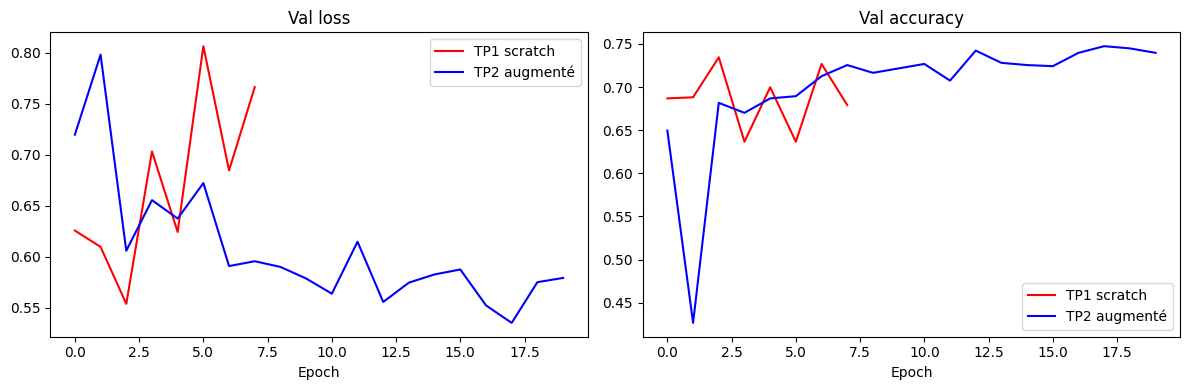

In [20]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_scratch.history['val_loss'], color='red', label='TP1 scratch')
plt.plot(history_augmented.history['val_loss'], color='blue', label='TP2 augmenté')
plt.title('Val loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_scratch.history['val_accuracy'], color='red', label='TP1 scratch')
plt.plot(history_augmented.history['val_accuracy'], color='blue', label='TP2 augmenté')
plt.title('Val accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.savefig("comparison_tp1_tp2.png", dpi=100)
plt.show()

In [23]:
def final_gap(history):
    # Écart train/val d'accuracy au dernier epoch : mesure robuste de la divergence.
    # (L'écart au meilleur epoch est masqué par restore_best_weights ; l'écart max
    # est pollué par le bruit de la val en début d'entraînement.)
    return history.history['accuracy'][-1] - history.history['val_accuracy'][-1]

print(f"{'Modèle':<22} {'val_acc':>8} {'gap final':>10} {'temps':>7} {'params':>10}")
print('-' * 61)
for name, hist, t, model in [
    ('TP1 scratch', history_scratch, training_time_scratch, model_scratch),
    ('TP2 augmenté+Dropout', history_augmented, training_time_augmented, model_augmented),
]:
    print(f"{name:<22} {max(hist.history['val_accuracy']):>7.1%} "
          f"{final_gap(hist):>9.1%} {t:>6.0f}s {model.count_params():>10,}")

Modèle                  val_acc  gap final   temps     params
-------------------------------------------------------------
TP1 scratch              73.5%     14.4%    239s  4,287,809
TP2 augmenté+Dropout     74.7%     -2.6%    628s  4,287,809


### Interprétation

**Ce qui a changé dans les courbes.** En TP1 (rouge), la val_loss atteint son minimum dès l'epoch 2 puis remonte franchement : le modèle mémorise le train set, l'EarlyStopping coupe à l'epoch 8. En TP2 (bleu), la val_loss descend régulièrement jusqu'à l'epoch 20 sans jamais diverger, et la val_accuracy grimpe de façon monotone après les oscillations du début.

**Le gap train/val s'est-il réduit ?** Nettement. L'écart train/val d'accuracy au dernier epoch passe de **+14,4 %** (TP1, train qui s'envole à 82 % pendant que la val stagne à 68 %) à **−2,6 %** (TP2, val légèrement au-dessus du train). L'overfitting est éliminé.

**Convergence plus lente ou plus rapide ?** Plus lente, et c'est voulu : l'augmentation change l'image à chaque batch et le Dropout éteint 40 % des activations, donc le modèle ne peut plus mémoriser et met plus d'epochs à progresser (628 s vs 239 s, EarlyStopping jamais déclenché contre epoch 8 en TP1). Convergence plus lente mais généralisation meilleure — le compromis attendu.

**Ce qui reste insuffisant.** Le gain d'accuracy est marginal (73,5 % → 74,7 %), dans le bruit run-à-run. C'est la limite de l'augmentation seule : elle régularise un modèle qui, de toute façon, part de zéro et n'a aucune connaissance préalable des images. Sur une tâche fine-grained comme bactérie vs virus, il manque des **représentations visuelles riches** que 3 000 radios ne suffisent pas à apprendre. C'est exactement ce que le transfer learning (TP3) va apporter.